# Fairness Study — Fraud Detection by Gender

Evaluate whether the fraud-detection model treats genders fairly. We train a Random
Forest on a sample of transactions, score a held-out test set at a realistic alert
budget, and compute group-fairness metrics with `aif360` (Disparate Impact,
Statistical Parity Difference, Equal Opportunity Difference, Theil Index).

Note: `gender` is label-encoded alphabetically, so **Female = 0** and **Male = 1**.

In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

In [30]:
from transaction_analysis.models.features import build_features

X, y = build_features()

print(f"Shape: {X.shape}")
print(f"Fraud rate: {y.mean():.4f}")
print(f"\nGender stats:\n{X['gender'].value_counts()}")

Shape: (13305915, 47)
Fraud rate: 0.0010

Gender stats:
gender
0    6815916
1    6489999
Name: count, dtype: int64


In [31]:
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=50000, replace=False)

X_sampled = X.iloc[sample_idx].reset_index(drop=True)
y_sampled = y.iloc[sample_idx].reset_index(drop=True)

# Pull gender out as the protected attribute and drop it from the model features
# so the classifier cannot use it directly.
gender_sampled = X_sampled["gender"].astype(int)
X_features = X_sampled.drop("gender", axis=1)

# Stratify on the fraud label so the rare positive class appears in both folds.
X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X_features, y_sampled, gender_sampled, test_size=0.3, random_state=42, stratify=y_sampled
)

print(f"Sample: {X_sampled.shape} | gender counts: {dict(gender_sampled.value_counts())}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train shape: (50000, 47), Gender shape: (50000,)
Gender value counts:
gender
0    25635
1    24365
Name: count, dtype: int64
Train shape: (35000, 46), Test shape: (15000, 46)
Gender test - NaN count: 0, unique values: [1 0]


In [ ]:
# class_weight="balanced" helps the trees split on the rare fraud signal.
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate only top ALERT_RATE percent of transactions by model
ALERT_RATE = 0.05
threshold = np.quantile(y_pred_proba, 1 - ALERT_RATE)
y_pred = (y_pred_proba >= threshold).astype(int)

recall = y_pred[y_test.values == 1].mean()
print(f"Alert rate: {ALERT_RATE:.0%} | threshold: {threshold:.4f} | flagged: {int(y_pred.sum())}")
print(f"Accuracy: {(y_pred == y_test).mean():.4f} | Fraud recall @ budget: {recall:.4f}")

Alert rate: 5% | threshold: 0.0972 | flagged: 750
Accuracy: 0.9495 | Fraud recall @ budget: 0.1818


In [33]:
# Create aif360 datasets for fairness analysis
# gender is label-encoded alphabetically by LabelEncoder => Female=0, Male=1
# We treat Female=0 as unprivileged and Male=1 as privileged.
test_df_gender = pd.DataFrame({"true": y_test.values, "gender": gender_test.values})

dataset_gender_true = BinaryLabelDataset(
    df=test_df_gender,
    label_names=["true"],
    protected_attribute_names=["gender"],
    favorable_label=1,
    unfavorable_label=0,
)

dataset_gender_pred = dataset_gender_true.copy()
dataset_gender_pred.labels = y_pred.reshape(-1, 1)

print("Datasets (ground truth + predictions) created for fairness analysis")

Datasets (ground truth + predictions) created for fairness analysis


In [34]:
# Fairness metrics for GENDER
metrics_gender = ClassificationMetric(
    dataset_gender_true,
    dataset_gender_pred,
    unprivileged_groups=[{"gender": 0}],
    privileged_groups=[{"gender": 1}],
)

fairness_gender = {
    "Disparate Impact": metrics_gender.disparate_impact(),
    "Statistical Parity Difference": metrics_gender.statistical_parity_difference(),
    "Equal Opportunity Difference": metrics_gender.equal_opportunity_difference(),
    "Theil Index": metrics_gender.theil_index(),
}

print("=== FAIRNESS METRICS BY GENDER ===")
for metric, value in fairness_gender.items():
    print(f"{metric}: {value:.4f}")

print("\n[Notes]")
print("Disparate Impact ~1.0 = fair | <0.8 or >1.25 = potential bias")
print("Statistical Parity Difference ~0 = fair")
print("Equal Opportunity Difference ~0 = fair")

=== FAIRNESS METRICS BY GENDER ===
Disparate Impact: 0.9323
Statistical Parity Difference: -0.0035
Equal Opportunity Difference: 0.0333
Theil Index: 0.0178

[Notes]
Disparate Impact ~1.0 = fair | <0.8 or >1.25 = potential bias
Statistical Parity Difference ~0 = fair
Equal Opportunity Difference ~0 = fair


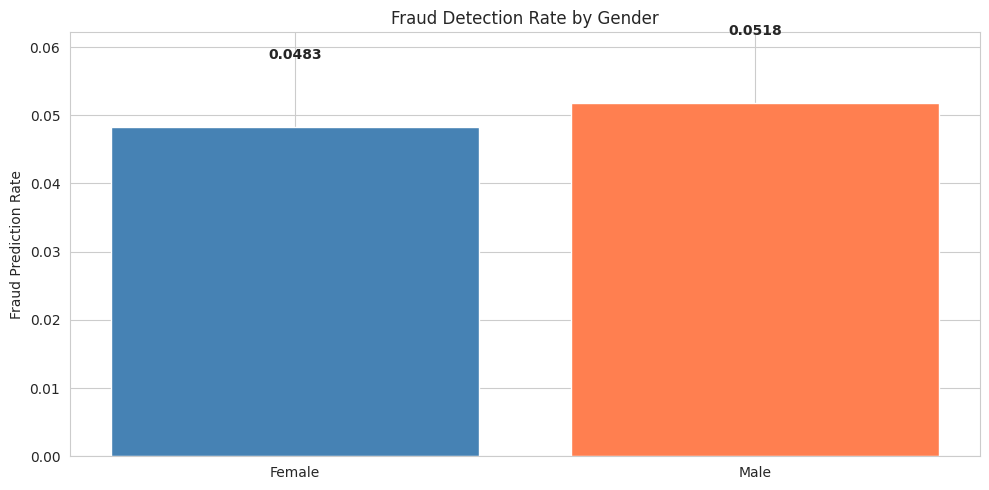

Prediction rate difference (Gender): 0.0035


In [35]:
from transaction_analysis.config.paths import PLOTS_DIR

# Compare prediction rates across groups
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# By Gender (LabelEncoder: Female=0, Male=1)
gender_names = {0: "Female", 1: "Male"}
pred_rate_gender = [y_pred[gender_test == g].mean() for g in [0, 1]]
ax.bar(list(gender_names.values()), pred_rate_gender, color=["steelblue", "coral"])
ax.set_ylabel("Fraud Prediction Rate")
ax.set_title("Fraud Detection Rate by Gender")
ax.set_ylim([0, max(pred_rate_gender) * 1.2])
for i, v in enumerate(pred_rate_gender):
    ax.text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/fairness_prediction_rates.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Prediction rate difference (Gender): {abs(pred_rate_gender[0] - pred_rate_gender[1]):.4f}")

In [36]:
# Summary
print("=" * 60)
print("FAIRNESS STUDY SUMMARY")
print("=" * 60)

# Gender fairness assessment
di_gender = fairness_gender["Disparate Impact"]
if np.isnan(di_gender):
    # Undefined when the privileged group has no predicted-positive cases
    gender_status = "UNDEFINED (too few positive predictions)"
elif 0.8 <= di_gender <= 1.25:
    gender_status = "FAIR"
else:
    gender_status = "BIASED"

print(f"\nGender Fairness: {gender_status}")
print(f"  - Disparate Impact: {di_gender:.4f}")
print(f"  - Fraud flag rate: Female {pred_rate_gender[0]:.4f} vs Male {pred_rate_gender[1]:.4f}")

print("\n" + "=" * 60)

FAIRNESS STUDY SUMMARY

Gender Fairness: FAIR
  - Disparate Impact: 0.9323
  - Model predicts fraud at different rates for Female (0.0482928729)    vs Male (0.0518021105)

